In [1]:
import pandas as pd
import pdb
import numpy as np
import matplotlib.pyplot as plt
pd.__version__

'2.3.2'

In [2]:
# read site listing data  - https://aqs.epa.gov/aqsweb/airdata/download_files.html#AQI
sites = pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/aqs_sites.zip')

In [4]:
sites.shape

(20730, 28)

In [3]:
sites.columns

Index(['State Code', 'County Code', 'Site Number', 'Latitude', 'Longitude',
       'Datum', 'Elevation', 'Land Use', 'Location Setting',
       'Site Established Date', 'Site Closed Date', 'Met Site State Code',
       'Met Site County Code', 'Met Site Site Number', 'Met Site Type',
       'Met Site Distance', 'Met Site Direction', 'GMT Offset',
       'Owning Agency', 'Local Site Name', 'Address', 'Zip Code', 'State Name',
       'County Name', 'City Name', 'CBSA Name', 'Tribe Name',
       'Extraction Date'],
      dtype='object')

In [6]:
sites.index

RangeIndex(start=0, stop=20730, step=1)

In [3]:
# use bitwise operators
# & for and 
# | for or 
sites.loc[sites['State Name'] == 'New York', ['State Code', 'County Code', 'Site Number', 'Location Setting', 'State Name', 'County Name', 'City Name']]
sites.loc[(sites['State Name'] == 'New York') & (sites['County Name'] == 'New York'), ['State Code', 'County Code', 'Site Number', 'Location Setting', 'State Name', 'County Name', 'City Name']]


,State Code,County Code,Site Number,Location Setting,State Name,County Name,City Name
12293,36,61,1,URBAN AND CENTER CITY,New York,New York,New York
12294,36,61,2,URBAN AND CENTER CITY,New York,New York,New York
12295,36,61,5,URBAN AND CENTER CITY,New York,New York,New York
12296,36,61,10,URBAN AND CENTER CITY,New York,New York,New York
12297,36,61,13,URBAN AND CENTER CITY,New York,New York,New York
12298,36,61,14,URBAN AND CENTER CITY,New York,New York,New York
12299,36,61,23,URBAN AND CENTER CITY,New York,New York,New York
12300,36,61,24,URBAN AND CENTER CITY,New York,New York,New York
12301,36,61,37,URBAN AND CENTER CITY,New York,New York,New York
12302,36,61,50,URBAN AND CENTER CITY,New York,New York,New York


In [4]:
# use bitwise operators
# & for and 
# | for or 
sites.loc[sites['State Name'] == 'New York', ['State Code', 'County Code', 'Site Number', 'Location Setting', 'State Name', 'County Name', 'City Name']]
sites.loc[(sites['State Name'] == 'New York') & (sites['County Name'] == 'Queens'), ['State Code', 'County Code', 'Site Number', 'Location Setting', 'State Name', 'County Name', 'City Name']]

,State Code,County Code,Site Number,Location Setting,State Name,County Name,City Name
12462,36,81,4,URBAN AND CENTER CITY,New York,Queens,New York
12463,36,81,8,SUBURBAN,New York,Queens,New York
12464,36,81,15,SUBURBAN,New York,Queens,New York
12465,36,81,16,SUBURBAN,New York,Queens,New York
12466,36,81,20,URBAN AND CENTER CITY,New York,Queens,New York
12467,36,81,26,URBAN AND CENTER CITY,New York,Queens,New York
12468,36,81,29,SUBURBAN,New York,Queens,New York
12469,36,81,30,SUBURBAN,New York,Queens,New York
12470,36,81,40,URBAN AND CENTER CITY,New York,Queens,New York
12471,36,81,41,URBAN AND CENTER CITY,New York,Queens,New York


In [4]:
pm25_daily_2020= pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/daily_88101_2020.zip', parse_dates=['Date Local'])
#pm25_daily_2019= pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/daily_88101_2019.zip', parse_dates=['Date Local']) 

In [5]:
pm25_daily_2020.columns

Index(['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC',
       'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration',
       'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type',
       'Observation Count', 'Observation Percent', 'Arithmetic Mean',
       '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name',
       'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name',
       'CBSA Name', 'Date of Last Change'],
      dtype='object')

In [7]:
pm25_daily_2020.loc[:, ['Site Num', 'Date Local', 'State Name', 'County Name','AQI'] ] 

,Site Num,Date Local,State Name,County Name,AQI
0,10,2020-01-01,Alabama,Baldwin,48.0
1,10,2020-01-04,Alabama,Baldwin,13.0
2,10,2020-01-07,Alabama,Baldwin,14.0
3,10,2020-01-10,Alabama,Baldwin,39.0
4,10,2020-01-13,Alabama,Baldwin,29.0
...,...,...,...,...,...
555293,14,2020-12-27,Country Of Mexico,BAJA CALIFORNIA NORTE,130.0
555294,14,2020-12-28,Country Of Mexico,BAJA CALIFORNIA NORTE,55.0
555295,14,2020-12-29,Country Of Mexico,BAJA CALIFORNIA NORTE,58.0
555296,14,2020-12-30,Country Of Mexico,BAJA CALIFORNIA NORTE,90.0


In [5]:
pm25_daily_2020_short = pm25_daily_2020[['Site Num', 'Date Local', 'State Name', 'County Name','AQI']]  

In [9]:
pm25_daily_2020_short

,Site Num,Date Local,State Name,County Name,AQI
0,10,2020-01-01,Alabama,Baldwin,48.0
1,10,2020-01-04,Alabama,Baldwin,13.0
2,10,2020-01-07,Alabama,Baldwin,14.0
3,10,2020-01-10,Alabama,Baldwin,39.0
4,10,2020-01-13,Alabama,Baldwin,29.0
...,...,...,...,...,...
555293,14,2020-12-27,Country Of Mexico,BAJA CALIFORNIA NORTE,130.0
555294,14,2020-12-28,Country Of Mexico,BAJA CALIFORNIA NORTE,55.0
555295,14,2020-12-29,Country Of Mexico,BAJA CALIFORNIA NORTE,58.0
555296,14,2020-12-30,Country Of Mexico,BAJA CALIFORNIA NORTE,90.0


In [6]:
# AQI_NY_2020 = pm25_daily_2020_short.loc[pm25_daily_2020['County Name']== 'New York', ['Date Local', 'AQI']]
AQI_NY_2020 = pm25_daily_2020_short.loc[pm25_daily_2020['County Name']== 'New York']
AQI_NY_2020[:50]



,Site Num,Date Local,State Name,County Name,AQI
422729,79,2020-01-01,New York,New York,13.0
422730,79,2020-01-04,New York,New York,56.0
422731,79,2020-01-07,New York,New York,46.0
422732,79,2020-01-10,New York,New York,34.0
422733,79,2020-01-13,New York,New York,43.0
422734,79,2020-01-16,New York,New York,44.0
422735,79,2020-01-19,New York,New York,29.0
422736,79,2020-01-22,New York,New York,54.0
422737,79,2020-01-25,New York,New York,39.0
422738,79,2020-01-28,New York,New York,9.0


In [7]:
AQI_NY_2020.shape

(131, 5)

In [8]:
# use pd.pivot_table to move up site num to columns 
# Here is a good reference - https://www.youtube.com/watch?v=9dz1fmBUF8U&ab_channel=Enthought
# Tidy: melt() 1:30:00
# Tidy: pivot_table() 2:18:00
# [Pandas.pivot_table at SciPy 2021](https://github.com/chendaniely/2021-07-13-scipy-pandas)

AQI_NY_2020.pivot_table(index=['Date Local', 'State Name', 'County Name'], columns='Site Num', values='AQI').shape

(72, 2)

In [9]:
# use pd.pivot_table to move up site num to columns 
# Here is a good reference - https://www.youtube.com/watch?v=9dz1fmBUF8U&ab_channel=Enthought
# Tidy: melt() 1:30:00
# Tidy: pivot_table() 2:18:00
# [Pandas.pivot_table at SciPy 2021](https://github.com/chendaniely/2021-07-13-scipy-pandas)

AQI_NY_2020_flattened = pd.DataFrame(AQI_NY_2020.pivot_table(index=['Date Local', 'State Name', 'County Name'],
                        columns='Site Num', values='AQI').reset_index() )


In [10]:
AQI_NY_2020_flattened.shape

(72, 5)

In [11]:
AQI_NY_2020_flattened

Site Num,Date Local,State Name,County Name,79,134
0,2020-01-01,New York,New York,13.0,22.0
1,2020-01-04,New York,New York,55.0,59.0
2,2020-01-07,New York,New York,46.0,52.0
3,2020-01-10,New York,New York,35.0,42.0
4,2020-01-13,New York,New York,43.0,55.0
...,...,...,...,...,...
67,2020-12-17,New York,New York,20.0,NaN
68,2020-12-20,New York,New York,65.0,NaN
69,2020-12-23,New York,New York,29.5,NaN
70,2020-12-26,New York,New York,39.0,NaN


In [22]:
AQI_NY_2020_NP = AQI_NY_2020_flattened.values

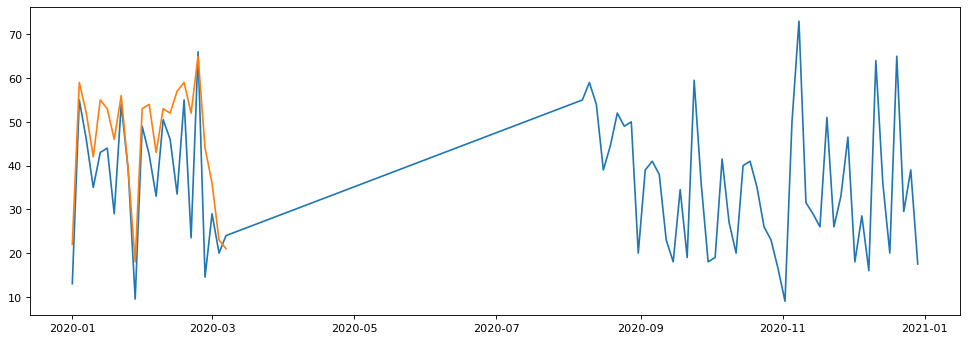

In [13]:
plt.figure(figsize=(15,5), dpi=80)
plt.plot(AQI_NY_2020_flattened.iloc[:,0], AQI_NY_2020_flattened.iloc[:,3])
plt.plot(AQI_NY_2020_flattened.iloc[:,0], AQI_NY_2020_flattened.iloc[:,4])